# 👋 Welcome to the Classwise Conformal Prediction Tutorial

In this tutorial, we will guide you through the use of **classwise conformal prediction** for classification tasks. Unlike standard conformal prediction methods (like LAC or APS) that provide marginal coverage guarantees, classwise methods aim to achieve **class-conditional coverage**, meaning the coverage guarantee holds for each class individually.

By the end of this notebook, you will be able to:
- Use the `ClasswiseLAC` method for classwise conformal prediction
- Evaluate classwise coverage and set sizes using dedicated metrics
- Compare standard LAC vs ClasswiseLAC
- Build your own classwise conformal predictor using the `ClasswiseCalibrator`

**Table of contents**

- [📊 Introduction to Classwise Conformal Prediction](#intro)
- [💾 Data Preparation](#data)
- [🔮 Prediction Model](#model)
- [⚙️ ClasswiseLAC: Basic Usage](#classwise-lac)
- [📏 Classwise Metrics](#metrics)
- [🔄 LAC vs ClasswiseLAC Comparison](#comparison)
- [🔧 Building a Custom Classwise Conformal Predictor](#custom)

**Links**
- [<img src="https://github.githubassets.com/images/icons/emoji/octocat.png" width=20> Github](https://github.com/deel-ai/puncc)
- [📘 Documentation](https://deel-ai.github.io/puncc/index.html)

**References**
- Ding et al. "Class-Conditional Conformal Prediction with Many Classes" (2023) - [arXiv:2306.09335](https://arxiv.org/abs/2306.09335)

In [1]:
import sys
sys.path.append('..')

## 📊 Introduction to Classwise Conformal Prediction <a class="anchor" id="intro"></a>

Standard conformal prediction methods like LAC (Least Ambiguous set-valued Classifier) provide **marginal coverage guarantees**:

$$P(Y \in \mathcal{C}(X)) \geq 1 - \alpha$$

This means that, on average across all classes, the true label is contained in the prediction set with probability at least $1-\alpha$.

However, this marginal guarantee does not ensure that each class is covered equally well. Some classes might be over-covered while others are under-covered.

**Classwise conformal prediction** aims to achieve **class-conditional coverage**:

$$P(Y \in \mathcal{C}(X) | Y = k) \geq 1 - \alpha \quad \forall k \in \{1, ..., K\}$$

This is achieved by computing separate quantiles for each class during calibration, rather than a single global quantile.

### How ClasswiseLAC Works

1. **Nonconformity Score**: For each calibration sample, the LAC score is computed: $s_i = 1 - \hat{p}(y_i | x_i)$
2. **Per-Class Quantiles**: Instead of computing a single quantile, we compute one quantile $\hat{q}_k$ for each class $k$ using only the scores from samples belonging to that class
3. **Prediction Set**: For a new sample, class $k$ is included if $1 - \hat{p}(k | x) \leq \hat{q}_k$

## 💾 Data Preparation <a class="anchor" id="data"></a>

We will use the MNIST dataset for this tutorial. MNIST contains 70,000 grayscale images of handwritten digits (0-9), each of size 28×28 pixels.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow import keras

# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

# Load MNIST Database
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocessing: reshaping and standardization
X_train = X_train.reshape((len(X_train), 28, 28))
X_train = X_train.astype('float32') / 255
X_test = X_test.reshape((len(X_test), 28, 28))
X_test = X_test.astype('float32') / 255

# Split fit and calib datasets
X_fit, X_calib = X_train[:50000], X_train[50000:]
y_fit, y_calib = y_train[:50000], y_train[50000:]

# One hot encoding of classes for training
y_fit_cat = to_categorical(y_fit)
y_calib_cat = to_categorical(y_calib)
y_test_cat = to_categorical(y_test)

print(f"Training set: {X_fit.shape[0]} samples")
print(f"Calibration set: {X_calib.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Number of classes: {len(np.unique(y_train))}")

2026-02-03 17:07:12.484737: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Training set: 50000 samples
Calibration set: 10000 samples
Test set: 10000 samples
Number of classes: 10


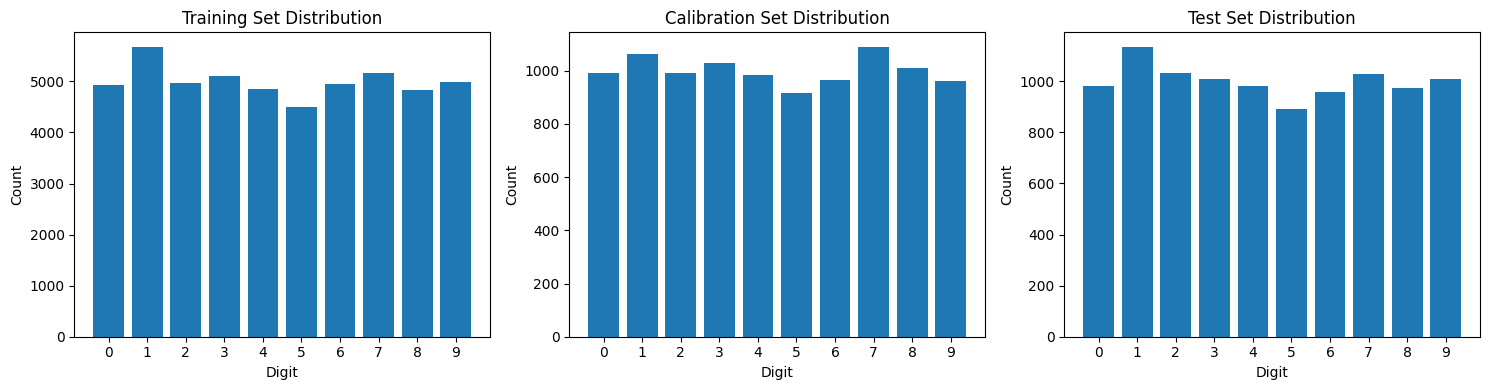

In [4]:
# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (data, title) in zip(axes, [(y_fit, 'Training'), (y_calib, 'Calibration'), (y_test, 'Test')]):
    counts = np.bincount(data, minlength=10)
    ax.bar(range(10), counts)
    ax.set_xlabel('Digit')
    ax.set_ylabel('Count')
    ax.set_title(f'{title} Set Distribution')
    ax.set_xticks(range(10))

plt.tight_layout()
plt.show()

## 🔮 Prediction Model <a class="anchor" id="model"></a>

We define a simple convolutional neural network (CNN) for digit classification. The same model will be used for both LAC and ClasswiseLAC to ensure a fair comparison.

In [5]:
from tensorflow.keras import layers

def create_model():
    """Create a simple CNN for MNIST classification."""
    model = keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(16, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(10, activation="softmax"),
    ])
    return model

# Display model architecture
model = create_model()
model.summary()

W0000 00:00:1770134897.398120  168974 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,810 (50.04 KB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 0 (0.00 B)

## ⚙️ ClasswiseLAC: Basic Usage <a class="anchor" id="classwise-lac"></a>

Now let's use the `ClasswiseLAC` method to create prediction sets with class-conditional coverage guarantees.

In [10]:
from deel.puncc.api.prediction import BasePredictor
from deel.puncc.classification import ClasswiseLAC

# Reset random seed
keras.utils.set_random_seed(42)

# Create the model
nn_model = create_model()

# Compilation configuration
compile_kwargs = {
    "optimizer": "adam",
    "loss": "categorical_crossentropy",
    "metrics": ["accuracy"]
}

# Training configuration
fit_kwargs = {
    "epochs": 2,
    "batch_size": 256,
    "validation_split": 0.1,
    "verbose": 1
}

# Wrap the model in a predictor
class_predictor = BasePredictor(nn_model, is_trained=False, **compile_kwargs)

# Create ClasswiseLAC conformal predictor
classwise_lac = ClasswiseLAC(class_predictor)

# Fit the model and calibrate
classwise_lac.fit(
    X_fit=X_fit,
    y_fit=y_fit_cat,
    X_calib=X_calib,
    y_calib=y_calib,
    **fit_kwargs
)

# Make predictions with alpha=0.1 (90% target coverage)
alpha = 0.01
y_pred_classwise, set_pred_classwise = classwise_lac.predict(X_test, alpha=alpha)

Epoch 1/2


176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8217 - loss: 0.6566 - val_accuracy: 0.9306 - val_loss: 0.2342
Epoch 2/2
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9531 - loss: 0.1609 - val_accuracy: 0.9536 - val_loss: 0.1528
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 789us/step


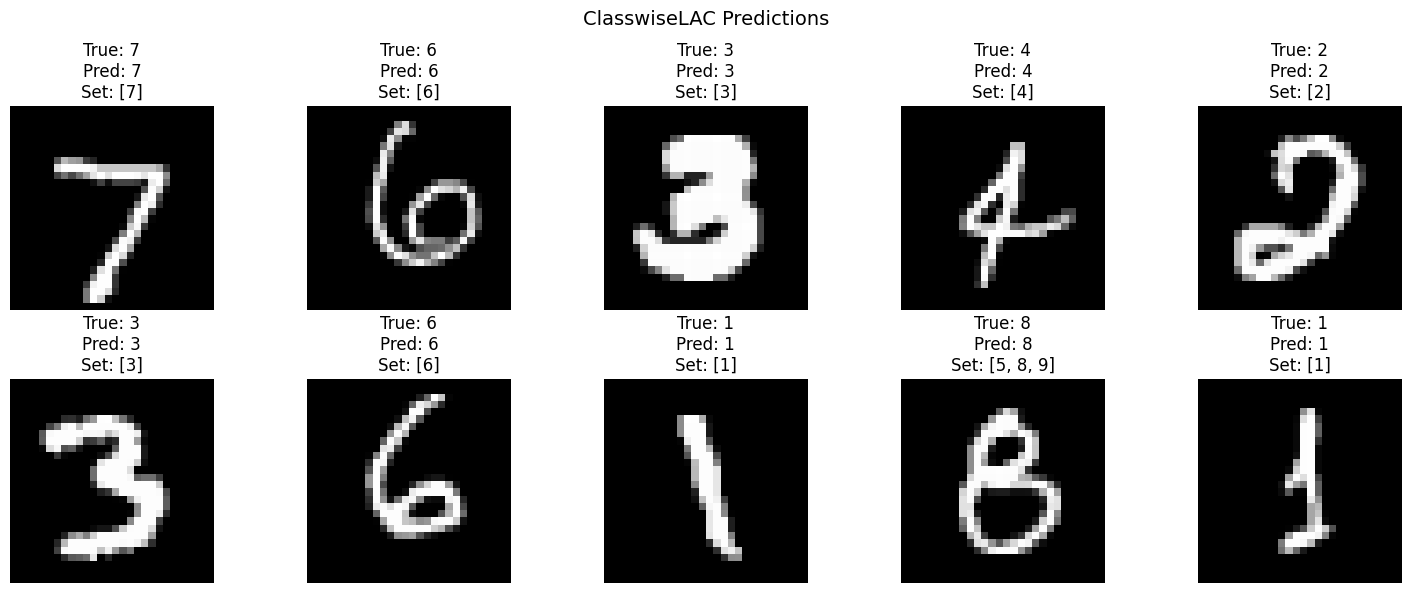

In [11]:
# Visualize some predictions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    idx = i * 100  # Sample indices
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    point_pred = np.argmax(y_pred_classwise[idx])
    ax.set_title(f"True: {y_test[idx]}\nPred: {point_pred}\nSet: {set_pred_classwise[idx]}")
    ax.axis('off')

plt.suptitle('ClasswiseLAC Predictions', fontsize=14)
plt.tight_layout()
plt.show()

## 📏 Classwise Metrics <a class="anchor" id="metrics"></a>

PUNCC provides dedicated metrics to evaluate classwise conformal prediction:

- **`classification_classwise_coverage`**: Computes coverage for each class separately
- **`classification_classwise_size`**: Computes average prediction set size for each class

These metrics help us verify that the class-conditional coverage guarantee is achieved.

In [12]:
from deel.puncc import metrics

# Compute marginal metrics
marginal_coverage = metrics.classification_mean_coverage(y_test, set_pred_classwise)
marginal_size = metrics.classification_mean_size(set_pred_classwise)

print("=" * 50)
print("MARGINAL METRICS")
print("=" * 50)
print(f"Marginal Coverage: {marginal_coverage:.3f} (target: {1-alpha:.2f})")
print(f"Average Set Size: {marginal_size:.3f}")

MARGINAL METRICS
Marginal Coverage: 0.991 (target: 0.99)
Average Set Size: 1.193


In [13]:
# Compute classwise metrics
n_classes = 10
classwise_coverage = metrics.classification_classwise_coverage(
    y_test, set_pred_classwise, n_classes=n_classes
)
classwise_size = metrics.classification_classwise_size(
    y_test, set_pred_classwise, n_classes=n_classes
)

print("\n" + "=" * 50)
print("CLASSWISE METRICS")
print("=" * 50)
print(f"{'Class':<10} {'Coverage':<15} {'Avg Set Size':<15}")
print("-" * 40)
for k in range(n_classes):
    print(f"{k:<10} {classwise_coverage[k]:<15.3f} {classwise_size[k]:<15.3f}")
print("-" * 40)
print(f"{'Mean':<10} {np.mean(classwise_coverage):<15.3f} {np.mean(classwise_size):<15.3f}")


CLASSWISE METRICS
Class      Coverage        Avg Set Size   
----------------------------------------
0          0.995           1.046          
1          0.993           1.059          
2          0.994           1.206          
3          0.991           1.228          
4          0.994           1.314          
5          0.997           1.211          
6          0.980           1.081          
7          0.984           1.200          
8          0.990           1.447          
9          0.994           1.160          
----------------------------------------
Mean       0.991           1.195          


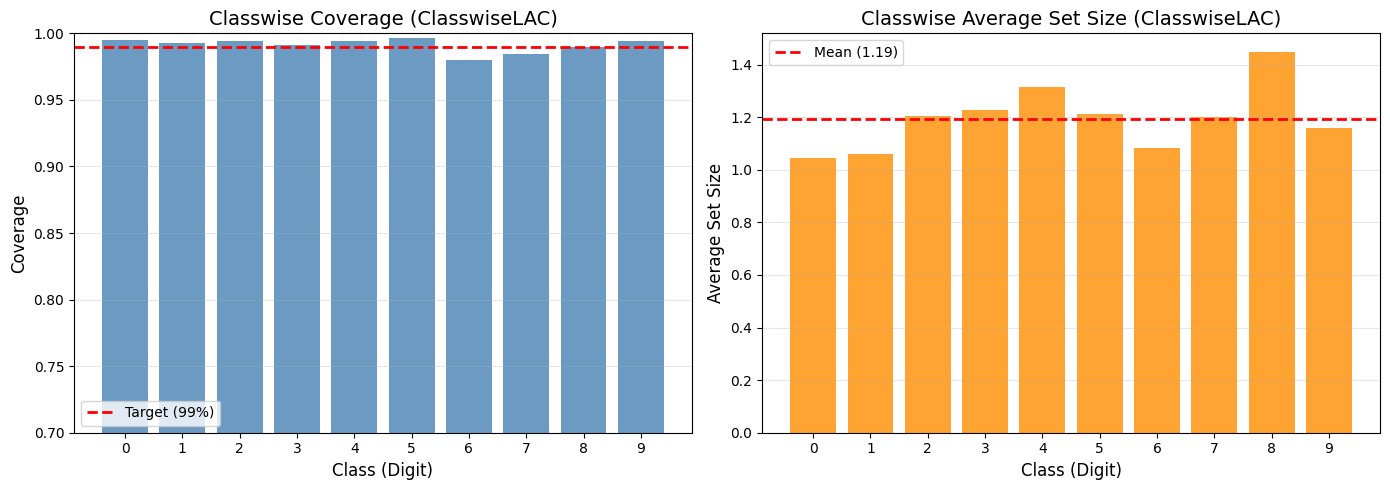

In [14]:
# Visualize classwise metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coverage plot
ax = axes[0]
bars = ax.bar(range(n_classes), classwise_coverage, color='steelblue', alpha=0.8)
ax.axhline(y=1-alpha, color='red', linestyle='--', linewidth=2, label=f'Target ({1-alpha:.0%})')
ax.set_xlabel('Class (Digit)', fontsize=12)
ax.set_ylabel('Coverage', fontsize=12)
ax.set_title('Classwise Coverage (ClasswiseLAC)', fontsize=14)
ax.set_xticks(range(n_classes))
ax.set_ylim(0.7, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Set size plot
ax = axes[1]
bars = ax.bar(range(n_classes), classwise_size, color='darkorange', alpha=0.8)
ax.axhline(y=marginal_size, color='red', linestyle='--', linewidth=2, label=f'Mean ({marginal_size:.2f})')
ax.set_xlabel('Class (Digit)', fontsize=12)
ax.set_ylabel('Average Set Size', fontsize=12)
ax.set_title('Classwise Average Set Size (ClasswiseLAC)', fontsize=14)
ax.set_xticks(range(n_classes))
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 🔄 LAC vs ClasswiseLAC Comparison <a class="anchor" id="comparison"></a>

Let's compare standard LAC with ClasswiseLAC to understand the difference between marginal and class-conditional coverage guarantees.

In [15]:
from deel.puncc.classification import LAC

# Reset random seed for fair comparison
keras.utils.set_random_seed(42)

# Create a new model for LAC
nn_model_lac = create_model()

# Wrap the model
lac_predictor = BasePredictor(nn_model_lac, is_trained=False, **compile_kwargs)

# Create LAC conformal predictor
lac = LAC(lac_predictor)

# Fit and calibrate
lac.fit(
    X_fit=X_fit,
    y_fit=y_fit_cat,
    X_calib=X_calib,
    y_calib=y_calib,
    **fit_kwargs
)

# Make predictions
y_pred_lac, set_pred_lac = lac.predict(X_test, alpha=alpha)

Epoch 1/2
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8217 - loss: 0.6566 - val_accuracy: 0.9306 - val_loss: 0.2342
Epoch 2/2
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9531 - loss: 0.1609 - val_accuracy: 0.9536 - val_loss: 0.1528
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 789us/step


In [16]:
# Compute metrics for LAC
lac_marginal_coverage = metrics.classification_mean_coverage(y_test, set_pred_lac)
lac_marginal_size = metrics.classification_mean_size(set_pred_lac)
lac_classwise_coverage = metrics.classification_classwise_coverage(
    y_test, set_pred_lac, n_classes=n_classes
)
lac_classwise_size = metrics.classification_classwise_size(
    y_test, set_pred_lac, n_classes=n_classes
)

# Print comparison
print("=" * 70)
print("COMPARISON: LAC vs ClasswiseLAC")
print("=" * 70)
print(f"\n{'Metric':<25} {'LAC':<20} {'ClasswiseLAC':<20}")
print("-" * 65)
print(f"{'Marginal Coverage':<25} {lac_marginal_coverage:<20.3f} {marginal_coverage:<20.3f}")
print(f"{'Average Set Size':<25} {lac_marginal_size:<20.3f} {marginal_size:<20.3f}")
print(f"{'Coverage Std (classes)':<25} {np.std(lac_classwise_coverage):<20.3f} {np.std(classwise_coverage):<20.3f}")
print(f"{'Min Class Coverage':<25} {np.min(lac_classwise_coverage):<20.3f} {np.min(classwise_coverage):<20.3f}")
print(f"{'Max Class Coverage':<25} {np.max(lac_classwise_coverage):<20.3f} {np.max(classwise_coverage):<20.3f}")

COMPARISON: LAC vs ClasswiseLAC

Metric                    LAC                  ClasswiseLAC        
-----------------------------------------------------------------
Marginal Coverage         0.990                0.991               
Average Set Size          1.144                1.193               
Coverage Std (classes)    0.005                0.005               
Min Class Coverage        0.978                0.980               
Max Class Coverage        0.997                0.997               


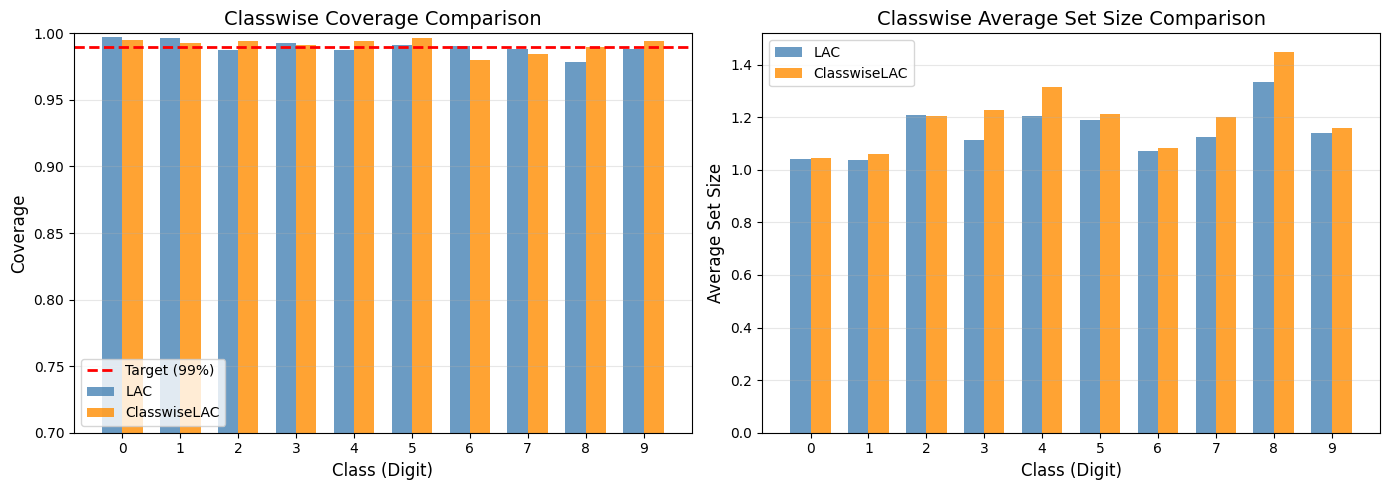

In [17]:
# Visual comparison of classwise coverage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(n_classes)
width = 0.35

# Coverage comparison
ax = axes[0]
bars1 = ax.bar(x - width/2, lac_classwise_coverage, width, label='LAC', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, classwise_coverage, width, label='ClasswiseLAC', color='darkorange', alpha=0.8)
ax.axhline(y=1-alpha, color='red', linestyle='--', linewidth=2, label=f'Target ({1-alpha:.0%})')
ax.set_xlabel('Class (Digit)', fontsize=12)
ax.set_ylabel('Coverage', fontsize=12)
ax.set_title('Classwise Coverage Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_ylim(0.7, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Set size comparison
ax = axes[1]
bars1 = ax.bar(x - width/2, lac_classwise_size, width, label='LAC', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, classwise_size, width, label='ClasswiseLAC', color='darkorange', alpha=0.8)
ax.set_xlabel('Class (Digit)', fontsize=12)
ax.set_ylabel('Average Set Size', fontsize=12)
ax.set_title('Classwise Average Set Size Comparison', fontsize=14)
ax.set_xticks(x)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Detailed per-class comparison table
print("\n" + "=" * 80)
print("DETAILED CLASSWISE COMPARISON")
print("=" * 80)
print(f"{'Class':<8} {'LAC Cov':<12} {'CW-LAC Cov':<12} {'LAC Size':<12} {'CW-LAC Size':<12}")
print("-" * 56)
for k in range(n_classes):
    print(f"{k:<8} {lac_classwise_coverage[k]:<12.3f} {classwise_coverage[k]:<12.3f} "
          f"{lac_classwise_size[k]:<12.3f} {classwise_size[k]:<12.3f}")
print("-" * 56)


DETAILED CLASSWISE COMPARISON
Class    LAC Cov      CW-LAC Cov   LAC Size     CW-LAC Size 
--------------------------------------------------------
0        0.997        0.995        1.041        1.046       
1        0.996        0.993        1.036        1.059       
2        0.987        0.994        1.208        1.206       
3        0.993        0.991        1.113        1.228       
4        0.988        0.994        1.204        1.314       
5        0.991        0.997        1.188        1.211       
6        0.991        0.980        1.070        1.081       
7        0.988        0.984        1.124        1.200       
8        0.978        0.990        1.335        1.447       
9        0.988        0.994        1.140        1.160       
--------------------------------------------------------


### Key Observations

- **LAC** provides marginal coverage but classwise coverage can vary significantly between classes
- **ClasswiseLAC** aims for more uniform coverage across all classes
- ClasswiseLAC may produce slightly larger prediction sets on average to achieve class-conditional coverage
- The trade-off is between marginal efficiency and fairness across classes

## 🔧 Building a Custom Classwise Conformal Predictor <a class="anchor" id="custom"></a>

In this section, we'll show how to build a classwise conformal predictor from scratch using the `ClasswiseCalibrator`. This is useful when you want to:
- Use a custom nonconformity score
- Understand the inner workings of classwise conformal prediction
- Extend the method for specific applications

We'll implement the LAC score manually and verify that our custom implementation gives the same results as `ClasswiseLAC`.

In [19]:
from deel.puncc.api.calibration import ClasswiseCalibrator
from deel.puncc.api.conformalization import ConformalPredictor
from deel.puncc.api.splitting import IdSplitter

### Step 1: Define the Nonconformity Score Function

For classwise conformal prediction, the nonconformity score function must return a 2D array of shape `(n_samples, n_classes)`, where:
- Each row corresponds to a sample
- Only the entry for the true class contains a valid score
- All other entries are `NaN`

This structure allows the `ClasswiseCalibrator` to compute per-class quantiles.

In [20]:
def custom_classwise_lac_score(Y_pred, y_true):
    """
    Custom classwise LAC nonconformity score.
    
    For each sample, computes the LAC score (1 - predicted probability of true class)
    and stores it only in the position corresponding to the true class.
    All other positions are filled with NaN.
    
    Parameters:
    -----------
    Y_pred : np.ndarray
        Predicted probabilities, shape (n_samples, n_classes)
    y_true : np.ndarray
        True labels, shape (n_samples,)
        
    Returns:
    --------
    np.ndarray
        Classwise scores, shape (n_samples, n_classes)
    """
    n_samples, n_classes = Y_pred.shape
    
    # Initialize with NaN
    scores = np.full((n_samples, n_classes), np.nan)
    
    # For each sample, compute LAC score only for the true class
    sample_indices = np.arange(n_samples)
    scores[sample_indices, y_true] = 1 - Y_pred[sample_indices, y_true]
    
    return scores

# Test the score function
print("Example of classwise LAC scores:")
example_probs = np.array([[0.7, 0.2, 0.1], [0.1, 0.8, 0.1], [0.3, 0.3, 0.4]])
example_labels = np.array([0, 1, 2])
example_scores = custom_classwise_lac_score(example_probs, example_labels)
print(f"Predicted probabilities:\n{example_probs}")
print(f"True labels: {example_labels}")
print(f"Classwise scores:\n{example_scores}")

Example of classwise LAC scores:
Predicted probabilities:
[[0.7 0.2 0.1]
 [0.1 0.8 0.1]
 [0.3 0.3 0.4]]
True labels: [0 1 2]
Classwise scores:
[[0.3 nan nan]
 [nan 0.2 nan]
 [nan nan 0.6]]


### Step 2: Define the Prediction Set Function

The prediction set function takes:
- `Y_pred`: predicted probabilities for test samples
- `scores_quantile`: per-class quantiles (one for each class)

It returns a tuple containing the prediction sets.

In [23]:
def custom_classwise_lac_set(Y_pred, scores_quantile):
    """
    Custom classwise LAC prediction set function.
    
    For each test sample and each class k, includes class k in the prediction set
    if the LAC score (1 - prob_k) <= quantile_k.
    
    Parameters:
    -----------
    Y_pred : np.ndarray
        Predicted probabilities, shape (n_samples, n_classes)
    scores_quantile : np.ndarray
        Per-class quantiles, shape (n_classes,)
        
    Returns:
    --------
    tuple
        Tuple containing list of prediction sets
    """
    n_samples, n_classes = Y_pred.shape
    
    # Compute LAC scores for all classes
    lac_scores = 1 - Y_pred  # Shape: (n_samples, n_classes)
    
    # Build prediction sets
    prediction_sets = []
    for i in range(n_samples):
        # Include class k if lac_score[k] <= quantile[k]
        pred_set = [k for k in range(n_classes) if lac_scores[i, k] <= scores_quantile[k]]
        prediction_sets.append(pred_set)
    
    return (prediction_sets,)

# Test the prediction set function
print("Example of prediction sets:")
example_quantiles = np.array([0.4, 0.3, 0.5])  # Per-class quantiles
example_sets = custom_classwise_lac_set(example_probs, example_quantiles)
print(f"Per-class quantiles: {example_quantiles}")
print(f"Prediction sets: {example_sets[0]}")

Example of prediction sets:
Per-class quantiles: [0.4 0.3 0.5]
Prediction sets: [[0], [1], []]


### Step 3: Create the ClasswiseCalibrator and ConformalPredictor

Now we assemble our custom components into a full conformal predictor.

In [24]:
# Reset random seed
keras.utils.set_random_seed(42)

# Create a new model for our custom implementation
nn_model_custom = create_model()

# Wrap the model
custom_predictor = BasePredictor(nn_model_custom, is_trained=False, **compile_kwargs)

# Create the ClasswiseCalibrator with our custom functions
custom_calibrator = ClasswiseCalibrator(
    nonconf_score_func=custom_classwise_lac_score,
    pred_set_func=custom_classwise_lac_set,
    weight_func=None
)

# Create a splitter for our data
splitter = IdSplitter(X_fit, y_fit_cat, X_calib, y_calib)

# Create the ConformalPredictor
custom_conformal_predictor = ConformalPredictor(
    predictor=custom_predictor,
    calibrator=custom_calibrator,
    splitter=splitter,
    train=True
)

In [25]:
# Fit the custom conformal predictor
custom_conformal_predictor.fit(X=None, y=None, **fit_kwargs)

# Make predictions
y_pred_custom, set_pred_custom = custom_conformal_predictor.predict(X_test, alpha=alpha)

Epoch 1/2
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8217 - loss: 0.6566 - val_accuracy: 0.9306 - val_loss: 0.2342
Epoch 2/2
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9531 - loss: 0.1609 - val_accuracy: 0.9536 - val_loss: 0.1528
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step


### Step 4: Verify Results

Let's verify that our custom implementation produces results consistent with the built-in `ClasswiseLAC`.

In [26]:
# Compute metrics for custom implementation
custom_marginal_coverage = metrics.classification_mean_coverage(y_test, set_pred_custom)
custom_marginal_size = metrics.classification_mean_size(set_pred_custom)
custom_classwise_coverage = metrics.classification_classwise_coverage(
    y_test, set_pred_custom, n_classes=n_classes
)
custom_classwise_size = metrics.classification_classwise_size(
    y_test, set_pred_custom, n_classes=n_classes
)

# Print comparison
print("=" * 70)
print("VERIFICATION: ClasswiseLAC vs Custom Implementation")
print("=" * 70)
print(f"\n{'Metric':<25} {'ClasswiseLAC':<20} {'Custom':<20}")
print("-" * 65)
print(f"{'Marginal Coverage':<25} {marginal_coverage:<20.3f} {custom_marginal_coverage:<20.3f}")
print(f"{'Average Set Size':<25} {marginal_size:<20.3f} {custom_marginal_size:<20.3f}")
print(f"{'Mean Class Coverage':<25} {np.mean(classwise_coverage):<20.3f} {np.mean(custom_classwise_coverage):<20.3f}")
print(f"{'Mean Class Size':<25} {np.mean(classwise_size):<20.3f} {np.mean(custom_classwise_size):<20.3f}")

VERIFICATION: ClasswiseLAC vs Custom Implementation

Metric                    ClasswiseLAC         Custom              
-----------------------------------------------------------------
Marginal Coverage         0.991                0.991               
Average Set Size          1.193                1.193               
Mean Class Coverage       0.991                0.991               
Mean Class Size           1.195                1.195               


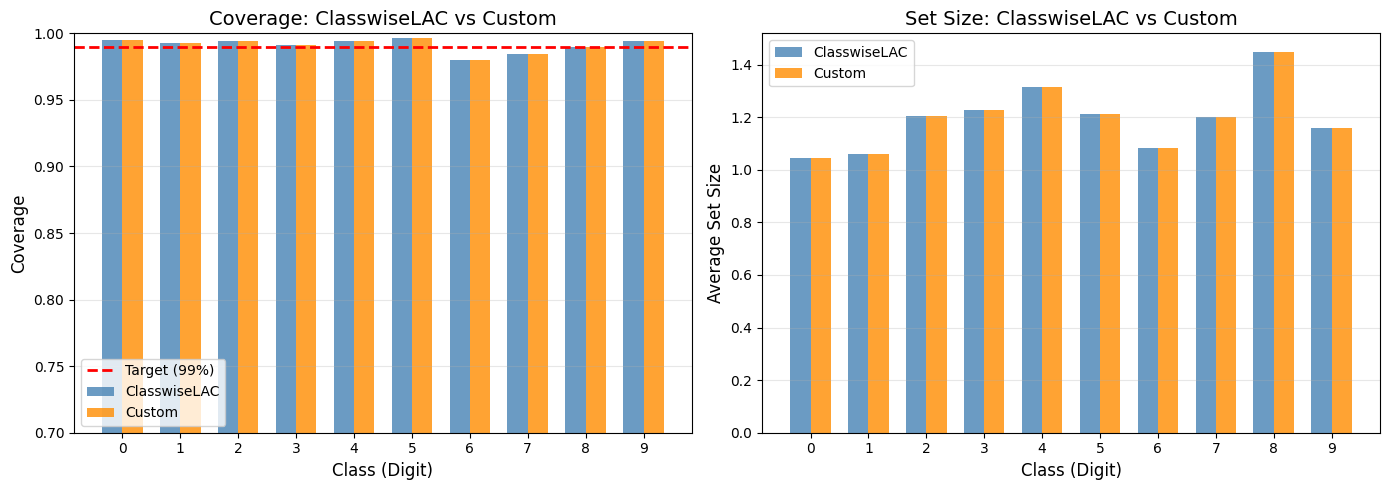

In [27]:
# Visual verification
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coverage comparison
ax = axes[0]
ax.bar(x - width/2, classwise_coverage, width, label='ClasswiseLAC', color='steelblue', alpha=0.8)
ax.bar(x + width/2, custom_classwise_coverage, width, label='Custom', color='darkorange', alpha=0.8)
ax.axhline(y=1-alpha, color='red', linestyle='--', linewidth=2, label=f'Target ({1-alpha:.0%})')
ax.set_xlabel('Class (Digit)', fontsize=12)
ax.set_ylabel('Coverage', fontsize=12)
ax.set_title('Coverage: ClasswiseLAC vs Custom', fontsize=14)
ax.set_xticks(x)
ax.set_ylim(0.7, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Set size comparison
ax = axes[1]
ax.bar(x - width/2, classwise_size, width, label='ClasswiseLAC', color='steelblue', alpha=0.8)
ax.bar(x + width/2, custom_classwise_size, width, label='Custom', color='darkorange', alpha=0.8)
ax.set_xlabel('Class (Digit)', fontsize=12)
ax.set_ylabel('Average Set Size', fontsize=12)
ax.set_title('Set Size: ClasswiseLAC vs Custom', fontsize=14)
ax.set_xticks(x)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Understanding the ClasswiseCalibrator

The key difference between `BaseCalibrator` and `ClasswiseCalibrator` is in how quantiles are computed:

- **BaseCalibrator**: Computes a single quantile from all nonconformity scores
- **ClasswiseCalibrator**: Computes one quantile per class, using only the scores from samples of that class

This is achieved by storing NaN values for non-true-class entries in the score matrix, and then computing quantiles while ignoring NaN values.

In [ ]:
# Let's inspect the calibration scores and quantiles
calib_scores = custom_calibrator.get_nonconformity_scores()
print(f"Calibration scores shape: {calib_scores.shape}")
print(f"\nFirst 5 rows of calibration scores (NaN = not the true class):")
print(calib_scores[:5])

# Count non-NaN entries per class
print(f"\nNumber of calibration samples per class:")
for k in range(n_classes):
    count = np.sum(~np.isnan(calib_scores[:, k]))
    print(f"  Class {k}: {count} samples")

# 🎉 Congratulations!

**You have learned how to use classwise conformal prediction with PUNCC!**

### Summary

In this tutorial, you learned:

1. **ClasswiseLAC basics**: How to use the `ClasswiseLAC` method for class-conditional coverage
2. **Classwise metrics**: How to evaluate performance using `classification_classwise_coverage` and `classification_classwise_size`
3. **LAC vs ClasswiseLAC**: The trade-offs between marginal and class-conditional coverage
4. **Custom implementation**: How to build your own classwise conformal predictor using `ClasswiseCalibrator`

### When to Use Classwise Conformal Prediction

Consider using classwise methods when:
- **Class imbalance**: Some classes are underrepresented and may have poor coverage with marginal methods
- **Fairness requirements**: You need equal coverage guarantees across all classes
- **High-stakes applications**: Missing certain classes (e.g., rare diseases) is particularly costly

### Further Reading

- [PUNCC Documentation](https://deel-ai.github.io/puncc/index.html)
- [Ding et al. "Class-Conditional Conformal Prediction with Many Classes"](https://arxiv.org/abs/2306.09335)
- [API Tutorial](api_intro.ipynb) for more advanced usage